# ACC102 Mini Assignment – Track 2 GitHub Data Analysis Project

**Project title:** What Drives AI Company Valuation? A Data-Based Comparison     
**Module:** ACC102 Artificial Intelligence-Driven Data Analytics      
**Track:** Track 2 – GitHub Data Analysis Project      
**Student name:** Chunhui Wang      
**Student ID:** 2472677      
**Date:** April 2026     

In [49]:
!pip install yfinance pandas matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import os

print("Libraries imported successfully.")

Libraries imported successfully.


In [50]:
# Project parameters
tickers = ["NVDA", "MSFT", "GOOGL", "META"]

start_date = "2022-01-01"
end_date = "2025-01-01"

print("Companies:", tickers)
print("Analysis period:", start_date, "to", end_date)

Companies: ['NVDA', 'MSFT', 'GOOGL', 'META']
Analysis period: 2022-01-01 to 2025-01-01


In [51]:
# Option 1: Download data from Yahoo Finance
# raw_data = yf.download(tickers, start=start_date, end=end_date, progress=False)
# close_prices = raw_data["Close"]

# Option 2: Load saved data locally for reproducibility
close_prices = pd.read_csv(
    "data/clean_ai_stock_prices.csv",
    index_col=0,
    parse_dates=True
)

close_prices.head()

,GOOGL,META,MSFT,NVDA
Date,,,,
2022-01-03,143.802979,335.904053,323.160797,30.061138
2022-01-04,143.215836,333.909637,317.619507,29.231789
2022-01-05,136.645630,321.645905,305.426727,27.549143
2022-01-06,136.618347,329.871307,303.013336,28.122000
2022-01-07,135.893860,329.206635,303.167816,27.192850


In [52]:
# Inspect the dataset
print("Shape of dataset:", close_prices.shape)

print("\nColumn names:")
print(close_prices.columns)

print("\nMissing values:")
print(close_prices.isna().sum())

print("\nBasic information:")
close_prices.info()

Shape of dataset: (753, 4)

Column names:
Index(['GOOGL', 'META', 'MSFT', 'NVDA'], dtype='object')

Missing values:
GOOGL    0
META     0
MSFT     0
NVDA     0
dtype: int64

Basic information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 753 entries, 2022-01-03 to 2024-12-31
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   GOOGL   753 non-null    float64
 1   META    753 non-null    float64
 2   MSFT    753 non-null    float64
 3   NVDA    753 non-null    float64
dtypes: float64(4)
memory usage: 29.4 KB


In [53]:
# Data cleaning
clean_prices = close_prices.dropna()

print("Original rows:", len(close_prices))
print("Rows after cleaning:", len(clean_prices))

clean_prices.head()

Original rows: 753
Rows after cleaning: 753


,GOOGL,META,MSFT,NVDA
Date,,,,
2022-01-03,143.802979,335.904053,323.160797,30.061138
2022-01-04,143.215836,333.909637,317.619507,29.231789
2022-01-05,136.645630,321.645905,305.426727,27.549143
2022-01-06,136.618347,329.871307,303.013336,28.122000
2022-01-07,135.893860,329.206635,303.167816,27.192850


In [54]:
# Save cleaned data
os.makedirs("data", exist_ok=True)

clean_prices.to_csv("data/clean_ai_stock_prices.csv")

print("Cleaned data saved to data/clean_ai_stock_prices.csv")

Cleaned data saved to data/clean_ai_stock_prices.csv


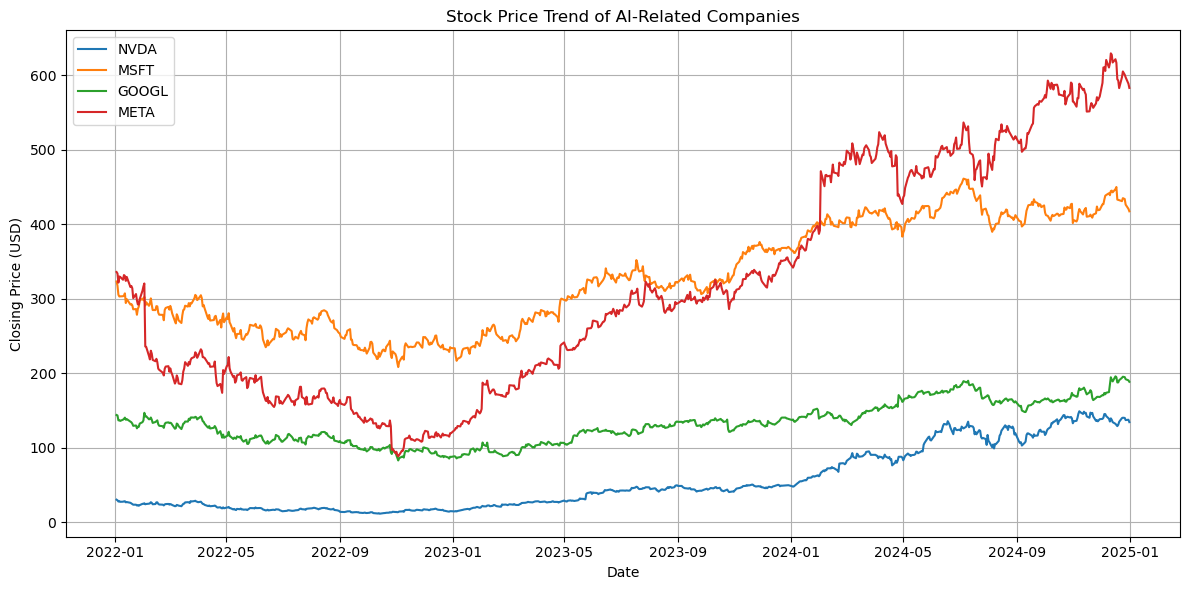

In [55]:
# Visualisation 1: stock price trend
plt.figure(figsize=(12, 6))

for ticker in tickers:
    plt.plot(clean_prices.index, clean_prices[ticker], label=ticker)

plt.title("Stock Price Trend of AI-Related Companies")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()

os.makedirs("figures", exist_ok=True)
plt.savefig("figures/price_trend.png", dpi=300)

plt.show()

In [56]:
# Calculate daily returns
daily_returns = clean_prices.pct_change().dropna()

daily_returns.head()

,GOOGL,META,MSFT,NVDA
Date,,,,
2022-01-04,-0.004083,-0.005937,-0.017147,-0.027589
2022-01-05,-0.045876,-0.036728,-0.038388,-0.057562
2022-01-06,-0.000200,0.025573,-0.007902,0.020794
2022-01-07,-0.005303,-0.002015,0.000510,-0.033040
2022-01-10,0.012060,-0.011212,0.000732,0.005615


In [57]:
# Descriptive statistics
return_stats = daily_returns.describe().T

return_stats = return_stats.rename(columns={
    "mean": "Average Daily Return",
    "std": "Daily Volatility",
    "min": "Worst Daily Return",
    "max": "Best Daily Return"
})

return_stats[["Average Daily Return", "Daily Volatility", "Worst Daily Return", "Best Daily Return"]]

,Average Daily Return,Daily Volatility,Worst Daily Return,Best Daily Return
GOOGL,0.000572,0.020627,-0.095094,0.102244
META,0.001212,0.030692,-0.263901,0.232824
MSFT,0.000491,0.017372,-0.077156,0.082268
NVDA,0.002588,0.034817,-0.100046,0.243696


In [58]:
# Annualised return and risk
annual_return = daily_returns.mean() * 252
annual_risk = daily_returns.std() * (252 ** 0.5)

risk_return_table = pd.DataFrame({
    "Annual Return": annual_return,
    "Annual Risk": annual_risk
})

risk_return_table = risk_return_table.sort_values(by="Annual Return", ascending=False)

risk_return_table

,Annual Return,Annual Risk
NVDA,0.652247,0.552710
META,0.305542,0.487222
GOOGL,0.144144,0.327441
MSFT,0.123791,0.275766


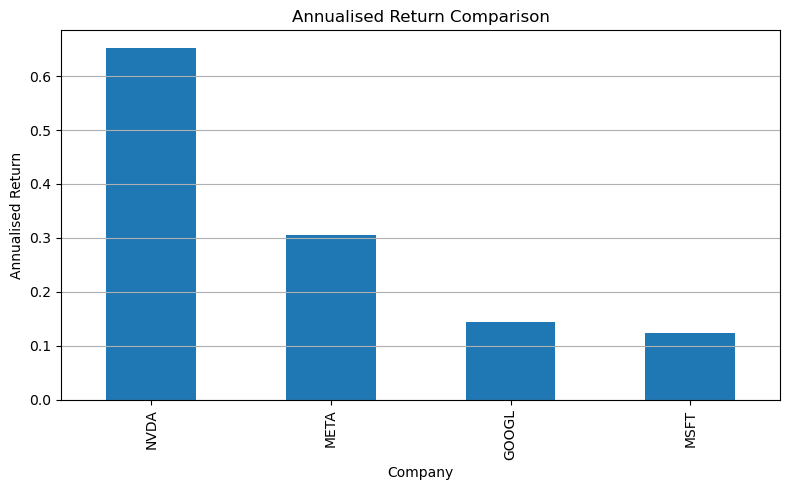

In [59]:
# Visualisation 2: annual return comparison
plt.figure(figsize=(8, 5))

risk_return_table["Annual Return"].plot(kind="bar")

plt.title("Annualised Return Comparison")
plt.xlabel("Company")
plt.ylabel("Annualised Return")
plt.grid(axis="y")
plt.tight_layout()

plt.savefig("figures/annual_return_comparison.png", dpi=300)

plt.show()

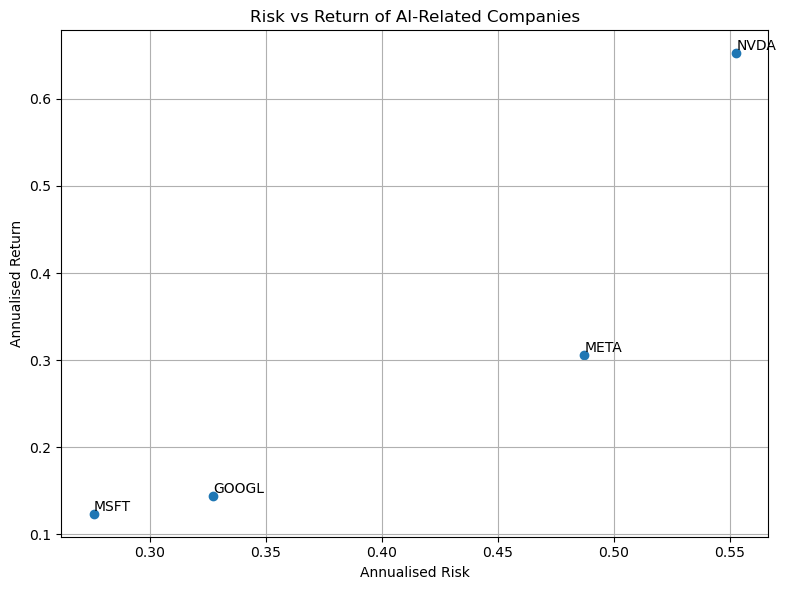

In [60]:
# Visualisation 3: risk vs return
plt.figure(figsize=(8, 6))

plt.scatter(
    risk_return_table["Annual Risk"],
    risk_return_table["Annual Return"]
)

for ticker in risk_return_table.index:
    x = risk_return_table.loc[ticker, "Annual Risk"]
    y = risk_return_table.loc[ticker, "Annual Return"]
    plt.text(x, y, ticker, fontsize=10, ha="left", va="bottom")

plt.title("Risk vs Return of AI-Related Companies")
plt.xlabel("Annualised Risk")
plt.ylabel("Annualised Return")
plt.grid(True)
plt.tight_layout()

plt.savefig("figures/risk_return.png", dpi=300)

plt.show()

In [61]:
# Normalised price index
normalised_prices = clean_prices / clean_prices.iloc[0] * 100

normalised_prices.head()

,GOOGL,META,MSFT,NVDA
Date,,,,
2022-01-03,100.000000,100.000000,100.000000,100.000000
2022-01-04,99.591703,99.406254,98.285284,97.241124
2022-01-05,95.022809,95.755291,94.512308,91.643712
2022-01-06,95.003837,98.204027,93.765500,93.549351
2022-01-07,94.500031,98.006151,93.813302,90.458485


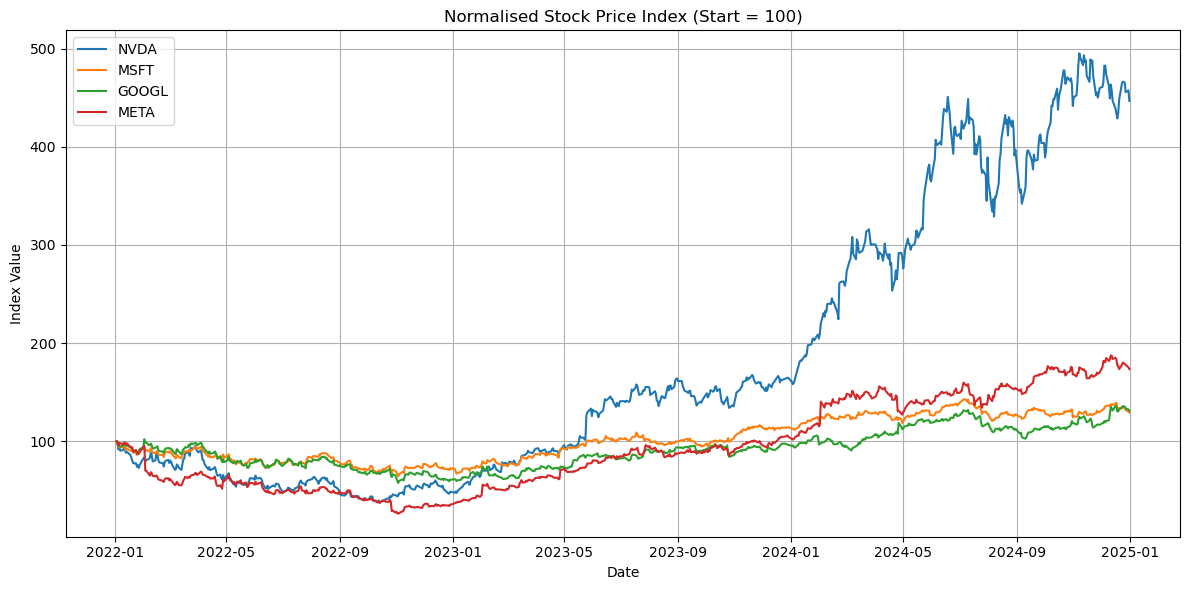

In [62]:
# Visualisation 4: normalised stock price index
plt.figure(figsize=(12, 6))

for ticker in tickers:
    plt.plot(normalised_prices.index, normalised_prices[ticker], label=ticker)

plt.title("Normalised Stock Price Index (Start = 100)")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("figures/normalised_price_index.png", dpi=300)

plt.show()

In [63]:
# Simple ranking system
ranking_table = risk_return_table.copy()

ranking_table["Return Rank"] = ranking_table["Annual Return"].rank(ascending=False)
ranking_table["Risk Rank"] = ranking_table["Annual Risk"].rank(ascending=True)

# Lower total score means better balance of return and risk
ranking_table["Total Score"] = (
    ranking_table["Return Rank"] + ranking_table["Risk Rank"]
)

ranking_table = ranking_table.sort_values(by="Total Score")

ranking_table

,Annual Return,Annual Risk,Return Rank,Risk Rank,Total Score
NVDA,0.652247,0.552710,1.0,4.0,5.0
META,0.305542,0.487222,2.0,3.0,5.0
GOOGL,0.144144,0.327441,3.0,2.0,5.0
MSFT,0.123791,0.275766,4.0,1.0,5.0


In [64]:
# Conditional interpretation using if, elif, else
def interpret_company(row):
    if (
        row["Annual Return"] > risk_return_table["Annual Return"].mean()
        and row["Annual Risk"] > risk_return_table["Annual Risk"].mean()
    ):
        return "High return, high risk"
    elif (
        row["Annual Return"] > risk_return_table["Annual Return"].mean()
        and row["Annual Risk"] <= risk_return_table["Annual Risk"].mean()
    ):
        return "High return, relatively lower risk"
    elif (
        row["Annual Return"] <= risk_return_table["Annual Return"].mean()
        and row["Annual Risk"] > risk_return_table["Annual Risk"].mean()
    ):
        return "Lower return, high risk"
    else:
        return "Lower return, relatively stable"


ranking_table["Interpretation"] = ranking_table.apply(interpret_company, axis=1)

ranking_table

,Annual Return,Annual Risk,Return Rank,Risk Rank,Total Score,Interpretation
NVDA,0.652247,0.552710,1.0,4.0,5.0,"High return, high risk"
META,0.305542,0.487222,2.0,3.0,5.0,"Lower return, high risk"
GOOGL,0.144144,0.327441,3.0,2.0,5.0,"Lower return, relatively stable"
MSFT,0.123791,0.275766,4.0,1.0,5.0,"Lower return, relatively stable"


In [65]:
# Export final summary
ranking_table.to_csv("data/final_risk_return_summary.csv")

print("Final summary saved to data/final_risk_return_summary.csv")

ranking_table

Final summary saved to data/final_risk_return_summary.csv


,Annual Return,Annual Risk,Return Rank,Risk Rank,Total Score,Interpretation
NVDA,0.652247,0.552710,1.0,4.0,5.0,"High return, high risk"
META,0.305542,0.487222,2.0,3.0,5.0,"Lower return, high risk"
GOOGL,0.144144,0.327441,3.0,2.0,5.0,"Lower return, relatively stable"
MSFT,0.123791,0.275766,4.0,1.0,5.0,"Lower return, relatively stable"


In [66]:
# Print simple findings
best_return_company = risk_return_table["Annual Return"].idxmax()
highest_risk_company = risk_return_table["Annual Risk"].idxmax()
best_balance_company = ranking_table.index[0]

print("Key Findings")
print("------------")
print("Company with the highest annualised return:", best_return_company)
print("Company with the highest annualised risk:", highest_risk_company)
print("Company with the best simple risk-return balance:", best_balance_company)

Key Findings
------------
Company with the highest annualised return: NVDA
Company with the highest annualised risk: NVDA
Company with the best simple risk-return balance: NVDA


In [67]:
# Final conclusion text
conclusion = """
This project shows that AI-related companies do not have the same risk-return profile.
Companies with higher growth potential may also have higher volatility.
This helps beginner investors and business students understand why AI company valuations
can rise quickly, but also why such valuations may involve uncertainty and risk.
"""

print(conclusion)


This project shows that AI-related companies do not have the same risk-return profile.
Companies with higher growth potential may also have higher volatility.
This helps beginner investors and business students understand why AI company valuations
can rise quickly, but also why such valuations may involve uncertainty and risk.

